# Bigram models: counts, likelihood and gradient descent

A count model and a neural model both predict the next character from one preceding character. This notebook separates the maximum-likelihood estimator, additive smoothing, and L2-regularised training, and reports data NLL separately from the optimisation objective.

The corpus is split by **unique spelling before constructing examples**, retaining duplicate-record weighting within each group. Training uses only train names; model comparisons use dev. Running every cell does not evaluate the test partition.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math
import platform
import random
import statistics
import time
from importlib.metadata import version

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, Image

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
ROOT = Path.cwd()  # open the notebook from the repository folder

NOTEBOOK_NAME = 'bigram.ipynb'

# words data, then encode characters and back
raw = (ROOT / 'names.txt').read_bytes()
words = raw.decode('utf-8').splitlines()
chars = ['.'] + sorted(set(''.join(words)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(chars)

# Split spellings first; repeated copies of a name must stay together.
unique_words = sorted(set(words))
random.Random(42).shuffle(unique_words)
n1, n2 = int(0.8 * len(unique_words)), int(0.9 * len(unique_words))
groups = {'train': set(unique_words[:n1]),
          'dev': set(unique_words[n1:n2]),
          'test': set(unique_words[n2:])}
assert groups['train'].isdisjoint(groups['dev'])
assert groups['train'].isdisjoint(groups['test'])
assert groups['dev'].isdisjoint(groups['test'])

# Preserve the original frequency of duplicate records within each partition.
train_words = [w for w in words if w in groups['train']]
dev_words = [w for w in words if w in groups['dev']]
test_words = [w for w in words if w in groups['test']]


# These two small helpers keep the saved split and seeds identical to the pilot.
def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True).encode()).hexdigest()

def stream_seed(seed, name):
    data = hashlib.sha256(f'{seed}:{name}'.encode()).digest()
    return int.from_bytes(data[:8], 'big') % (2**63 - 1)

def generator(seed, name):
    return torch.Generator().manual_seed(stream_seed(seed, name))

split = {
    'schema_version': 1,
    'policy': 'group_by_exact_spelling_keep_duplicates',
    'split_seed': 42,
    'source_sha256': hashlib.sha256(raw).hexdigest(),
    'vocabulary': chars,
    'groups': {name: sorted(group) for name, group in groups.items()},
    'counts': {},
}
for name, records in [('train', train_words), ('dev', dev_words), ('test', test_words)]:
    split['counts'][name] = {'records': len(records),
                             'unique_names': len(groups[name]),
                             'targets': sum(len(w) + 1 for w in records)}
split['split_id'] = digest(split)
print(split['counts'])

{'train': {'records': 25640, 'unique_names': 23595, 'targets': 182666}, 'dev': {'records': 3196, 'unique_names': 2949, 'targets': 22801}, 'test': {'records': 3197, 'unique_names': 2950, 'targets': 22679}}


## Counting transitions

The boundary symbol `.` starts and ends a name. Each row of the transition matrix corresponds to the preceding character. Without smoothing, dividing a row by its total gives its empirical conditional distribution, the maximum-likelihood estimate. If an entire row was unobserved, its MLE is unidentified; the helper chooses a uniform row.

In [2]:
def transition_counts(words):
    N = torch.zeros((vocab_size, vocab_size), dtype=torch.float64)
    for w in words:
        chs = ['.'] + list(w) + ['.']
        for ch1, ch2 in zip(chs, chs[1:]):
            ix1, ix2 = stoi[ch1], stoi[ch2]
            N[ix1, ix2] += 1
    return N

def count_probabilities(N, smoothing=0):
    P = N + smoothing
    for row in range(vocab_size):
        total = P[row].sum()
        if total > 0:
            P[row] /= total
        else:
            P[row] = 1 / vocab_size  # an unobserved row has no identified MLE
    return P

def bigram_nll(P, N):
    observed = N > 0
    return -(N[observed] * P[observed].log()).sum().item() / N.sum().item()

N_train = transition_counts(train_words)
N_dev = transition_counts(dev_words)
P_mle = count_probabilities(N_train, smoothing=0)
P_add_one = count_probabilities(N_train, smoothing=1)
for name, P in [('unsmoothed MLE', P_mle), ('add-one smoothing', P_add_one)]:
    print(f'{name:20s} train NLL {bigram_nll(P, N_train):.6f}; dev NLL {bigram_nll(P, N_dev):.6f}')
print('Unseen dev transitions:', int(N_dev[P_mle == 0].sum().item()))

unsmoothed MLE       train NLL 2.453615; dev NLL inf
add-one smoothing    train NLL 2.454379; dev NLL 2.457067
Unseen dev transitions: 9


Loss is average next-character NLL, in nats, including the final boundary token. Unsmoothed NLL is infinite if a held-out transition has probability zero. Add-one smoothing avoids that issue by changing the estimator; it does not leave the MLE unchanged.

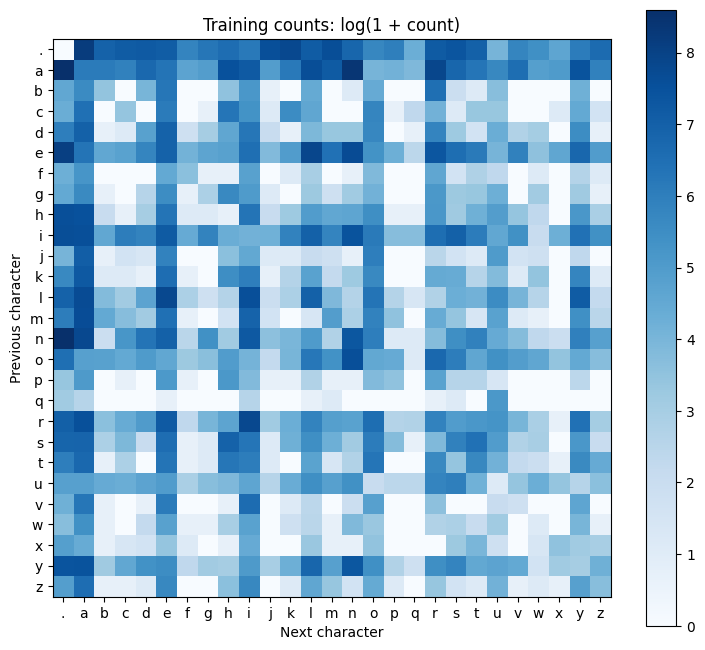

In [3]:
fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(torch.log1p(N_train).numpy(), cmap='Blues')
ax.set_xticks(range(len(chars)), chars)
ax.set_yticks(range(len(chars)), chars)
ax.set(xlabel='Next character', ylabel='Previous character', title='Training counts: log(1 + count)')
fig.colorbar(image, ax=ax)
plt.show()

## A neural parameterisation of the same context

A one-hot row multiplied by `W` selects the corresponding logits. The demonstration
below checks that directly. The training loop then groups repeated transitions by
their counts: each term receives the same weight it would have in the full list
of one-hot examples. This gives the same full-batch objective and gradient, with
much less repeated work. The loss and every update are written out below.

In [4]:
g = generator(0, 'one-hot-demo')
W_example = torch.randn((len(chars), len(chars)), generator=g, dtype=torch.float64)
indices = torch.tensor([stoi['a'], stoi['b'], stoi['a']])
one_hot = F.one_hot(indices, num_classes=len(chars)).double()
assert torch.equal(one_hot @ W_example, W_example[indices])
print('One-hot shape:', tuple(one_hot.shape), 'logit shape:', tuple((one_hot @ W_example).shape))

One-hot shape: (3, 27) logit shape: (3, 27)


## Compare unregularised and regularised training

An unregularised softmax model can approach the count-model optimum. Exact zero probabilities require a limit of logits, and finite optimisation need not reach that limit.

The regularised objective is data NLL plus an L2 penalty on the logits. Add-one smoothing and this penalty both discourage extreme predictions, but they are different objectives. Report all three quantities: data NLL, penalty, and their sum.

In [5]:
def train_neural_bigram(N, steps=2000, lr=50.0, l2=.01, seed=0):
    W = torch.randn(N.shape, generator=generator(seed, 'bigram'),
                    dtype=N.dtype, requires_grad=True)
    weights = N / N.sum()
    history = []
    for k in range(steps):
        # forward: mean data NLL plus a separately labelled penalty
        log_probs = F.log_softmax(W, dim=1)
        data_nll = -(weights * log_probs).sum()
        penalty = l2 * W.square().mean()
        loss = data_nll + penalty
        if k % 10 == 0:
            history.append({'step': k, 'nll': data_nll.item(),
                            'penalty': penalty.item(), 'objective': loss.item()})
        # backward and update
        W.grad = None
        loss.backward()
        with torch.no_grad():
            W.add_(W.grad, alpha=-lr)

    # Recompute the reported loss after the last update.
    with torch.no_grad():
        data_nll = -(weights * F.log_softmax(W, dim=1)).sum()
        penalty = l2 * W.square().mean()
        loss = data_nll + penalty
        history.append({'step': steps, 'nll': data_nll.item(),
                        'penalty': penalty.item(), 'objective': loss.item()})
    return {'weights': W.detach(), 'probabilities': W.detach().softmax(dim=1),
            'nll': data_nll.item(), 'penalty': penalty.item(), 'objective': loss.item(),
            'history': history, 'config': {'steps': steps, 'lr': lr, 'l2': l2, 'seed': seed}}

In [6]:
neural_mle = train_neural_bigram(N_train, steps=2000, lr=50.0, l2=0.0, seed=0)
neural_l2 = train_neural_bigram(N_train, steps=2000, lr=50.0, l2=0.01, seed=0)
for name, run in [('neural, no penalty', neural_mle), ('neural, L2 penalty', neural_l2)]:
    print(f"{name:20s} train NLL {run['nll']:.6f}; penalty {run['penalty']:.6f}; "
          f"objective {run['objective']:.6f}; dev NLL {bigram_nll(run['probabilities'], N_dev):.6f}")
    assert abs(run['objective'] - run['nll'] - run['penalty']) < 1e-12

neural, no penalty   train NLL 2.454267; penalty 0.000000; objective 2.454267; dev NLL 2.456855
neural, L2 penalty   train NLL 2.460110; penalty 0.020089; objective 2.480198; dev NLL 2.461648


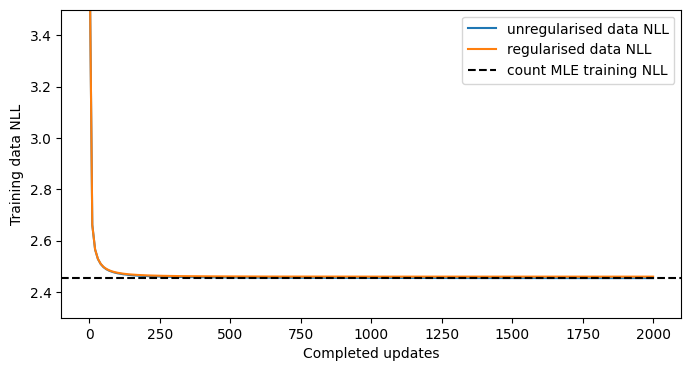

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, run in [('unregularised data NLL', neural_mle), ('regularised data NLL', neural_l2)]:
    ax.plot([r['step'] for r in run['history']], [r['nll'] for r in run['history']], label=name)
ax.axhline(bigram_nll(P_mle, N_train), linestyle='--', color='black', label='count MLE training NLL')
ax.set(xlabel='Completed updates', ylabel='Training data NLL', ylim=(2.3, 3.5))
ax.legend()
plt.show()

## Sampling

Sampling has its own random generator. A maximum length prevents an unbounded loop; a truncated sample is labelled explicitly. Generated examples illustrate model behaviour and are not a held-out quality metric.

In [8]:
def sample_bigram(P, seed=123, n=10, max_length=30):
    g = generator(seed, 'bigram-sampling')
    samples = []
    for _ in range(n):
        index, letters, ended = 0, [], False
        for _ in range(max_length + 1):
            index = torch.multinomial(P[index], 1, generator=g).item()
            if index == 0:
                ended = True
                break
            if len(letters) == max_length:
                break
            letters.append(chars[index])
        samples.append({'name': ''.join(letters), 'terminated': ended})
    return samples

samples = sample_bigram(neural_l2['probabilities'])
for sample in samples:
    print(sample['name'], '' if sample['terminated'] else '[truncated]')

jo 
abrylllis 
sul 
sonir 
ghiskekyo 
lianan 
n 
meondeenfr 
ve 
alajizaenca 


## Save the run

Each execution creates a new local result directory, including the exact split and neural training settings. No test loss is computed. Infinite unsmoothed dev NLL is represented by `null` together with an explicit `finite` flag in JSON.

In [9]:

# File writing is kept separate from the model and training loop.
def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, indent=2, sort_keys=True, allow_nan=False) + '\n')

def environment():
    notebook = json.loads((ROOT / NOTEBOOK_NAME).read_text())
    source = '\n'.join(''.join(c['source']) for c in notebook['cells']
                       if c['cell_type'] == 'code')
    return {'python': platform.python_version(), 'torch': torch.__version__,
            'numpy': version('numpy'), 'matplotlib': version('matplotlib'),
            'platform': platform.platform(), 'threads': torch.get_num_threads(),
            'device': 'cpu', 'dtype': 'float64',
            'implementation': NOTEBOOK_NAME,
            'core_code_sha256': hashlib.sha256(source.encode()).hexdigest()}

stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
output = ROOT / 'results' / 'local' / f'bigram-{stamp}'
output.mkdir(parents=True, exist_ok=False)

def finite_metric(value):
    return {'value': value if math.isfinite(value) else None, 'finite': math.isfinite(value)}

report = {'split_id': split['split_id'], 'environment': environment(), 'models': {}}
for name, P in [('count_mle', P_mle), ('count_add_one', P_add_one)]:
    report['models'][name] = {'train_nll': finite_metric(bigram_nll(P, N_train)),
                             'dev_nll': finite_metric(bigram_nll(P, N_dev))}
for name, run in [('neural_unregularised', neural_mle), ('neural_l2', neural_l2)]:
    report['models'][name] = {key: run[key] for key in ['nll', 'penalty', 'objective', 'history', 'config']}
    report['models'][name]['dev_nll'] = bigram_nll(run['probabilities'], N_dev)
    torch.save(run['weights'], output / f'{name}.pt')
write_json(output / 'result.json', report)
write_json(output / 'split.json', split)
print('Saved:', output.relative_to(ROOT))

Saved: results/local/bigram-20260919T204953762823Z
